# Phase 1 — ML models and SHAP

Issue #18. Compare Random Forest, XGBoost, and Elastic Net on FD001 raw inputs, then causal engineered features. Both variants share engine-level splits, uncapped targets, model grids, and metrics. All analysis uses official training engines. Internal validation scores cover every cycle of held-out training engines; official last-cycle test evaluation belongs to #6.

Preprocessing is fitted inside each CV pipeline. The all-training matrices exported by #15 are **not** used for tuning. SHAP explains model predictions and is not evidence of causation.

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import GridSearchCV

from rul.data.load import load_subset
from rul.data.labels import add_train_rul
from rul.data.split import holdout_split, group_kfold_splits
from rul.evaluation.metrics import evaluate
from rul.models.experiment import make_comparison_models, COMPARISON_GRIDS

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
SEED = 42
N_SPLITS = 3
raw = add_train_rul(load_subset("FD001", data_dir=ROOT / "data/raw/CMAPSSData").train)
train_idx, valid_idx = holdout_split(raw, 0.2, seed=SEED)
training = raw.iloc[train_idx].copy()
validation = raw.iloc[valid_idx].copy()
folds = list(group_kfold_splits(training, n_splits=N_SPLITS, seed=SEED))
assert set(training.unit).isdisjoint(validation.unit)
for left, right in folds:
    assert set(training.iloc[left].unit).isdisjoint(training.iloc[right].unit)
print(f"Training: {training.unit.nunique()} engines; holdout: {validation.unit.nunique()} engines")
cache = TemporaryDirectory(prefix="rul-cv-")
searches, rows, cv_tables = {}, [], []
holdout_scores = {}


Training: 80 engines; holdout: 20 engines


## 1. Raw-feature baseline

The baseline uses cycle, operating settings, and all 21 raw sensors. The engineered variant will select sensors from each training fold, fit regime normalization on that fold, then add trailing means, slopes, and signed health changes over 5, 10, and 20 cycles. Elastic Net scaling remains in its model pipeline.

Each model searches four candidates with three shared engine-level folds, selecting mean CV RMSE. Forests use 50/100 trees, `max_features=0.5`, and leaf sizes 1/3; XGBoost uses 100/200 trees and depths 3/5; Elastic Net uses alpha 0.1/1 and L1 ratios 0.2/0.8. These are modest reproducible grids, not a claim of globally optimal parameters. One worker limits RAM; temporary disk caching reuses fold transformations.

In [2]:
for variant in ("raw", "engineered"):
    searches[variant] = {}
    for name, pipeline in make_comparison_models(engineered=variant == "engineered", seed=SEED).items():
        print(f"Tuning {variant}: {name}", flush=True)
        pipeline.memory = cache.name
        search = GridSearchCV(pipeline, COMPARISON_GRIDS[name], cv=folds,
                              scoring="neg_root_mean_squared_error", n_jobs=1, refit=True,
                              error_score="raise")
        search.fit(training, training["rul"])
        searches[variant][name] = search
        metrics = evaluate(validation["rul"], search.predict(validation))
        holdout_scores[(variant, name)] = metrics
        rows.append({"features": variant, "model": name, "cv_rmse": -search.best_score_,
                     "holdout_rmse": metrics["rmse"], "holdout_mae": metrics["mae"],
                     "holdout_nasa": metrics["nasa_score"], "best_params": search.best_params_})
        candidates = pd.DataFrame(search.cv_results_)
        candidates["features"], candidates["model"] = variant, name
        candidates["cv_rmse"] = -candidates["mean_test_score"]
        cv_tables.append(candidates[["features", "model", "params", "cv_rmse", "std_test_score", "rank_test_score"]])
results = pd.DataFrame(rows)
cv_results = pd.concat(cv_tables, ignore_index=True)
display(results)
display(cv_results)


Tuning raw: random_forest


Tuning raw: xgboost


Tuning raw: elastic_net


Tuning engineered: random_forest


Tuning engineered: xgboost


Tuning engineered: elastic_net


,features,model,cv_rmse,holdout_rmse,holdout_mae,holdout_nasa,best_params
0,raw,random_forest,39.157985,30.758790,23.381857,246799.418515,"{'model__min_samples_leaf': 3, 'model__n_estim..."
1,raw,xgboost,39.891757,30.904057,23.544431,265626.251353,"{'model__max_depth': 3, 'model__n_estimators':..."
2,raw,elastic_net,42.650644,31.740009,25.195312,316560.066692,"{'model__model__alpha': 0.1, 'model__model__l1..."
3,engineered,random_forest,39.265344,26.471740,18.963176,210020.581520,"{'model__min_samples_leaf': 3, 'model__n_estim..."
4,engineered,xgboost,40.870579,30.329780,22.519657,390804.992302,"{'model__max_depth': 3, 'model__n_estimators':..."
5,engineered,elastic_net,42.882245,33.628305,27.564949,290491.647655,"{'model__model__alpha': 1.0, 'model__model__l1..."


,features,model,params,cv_rmse,std_test_score,rank_test_score
0,raw,random_forest,"{'model__min_samples_leaf': 1, 'model__n_estim...",39.451291,2.656823,4
1,raw,random_forest,"{'model__min_samples_leaf': 1, 'model__n_estim...",39.288345,2.671837,2
2,raw,random_forest,"{'model__min_samples_leaf': 3, 'model__n_estim...",39.360416,2.767138,3
3,raw,random_forest,"{'model__min_samples_leaf': 3, 'model__n_estim...",39.157985,2.784818,1
4,raw,xgboost,"{'model__max_depth': 3, 'model__n_estimators':...",39.891757,2.922296,1
5,raw,xgboost,"{'model__max_depth': 3, 'model__n_estimators':...",40.462989,2.859048,2
6,raw,xgboost,"{'model__max_depth': 5, 'model__n_estimators':...",41.493542,2.716359,3
7,raw,xgboost,"{'model__max_depth': 5, 'model__n_estimators':...",42.558717,2.670349,4
8,raw,elastic_net,"{'model__model__alpha': 0.1, 'model__model__l1...",42.664322,2.735391,2
9,raw,elastic_net,"{'model__model__alpha': 0.1, 'model__model__l1...",42.650644,2.851647,1


## Matched comparison
Lower RMSE/MAE is better. NASA scores are summed over the same held-out cycles; they are not official end-of-life test scores. All 24 candidate configurations and their fold variability appear above. Hyperparameters are chosen using CV only.

features,engineered,raw
model,,
elastic_net,33.628305,31.740009
random_forest,26.471740,30.758790
xgboost,30.329780,30.904057


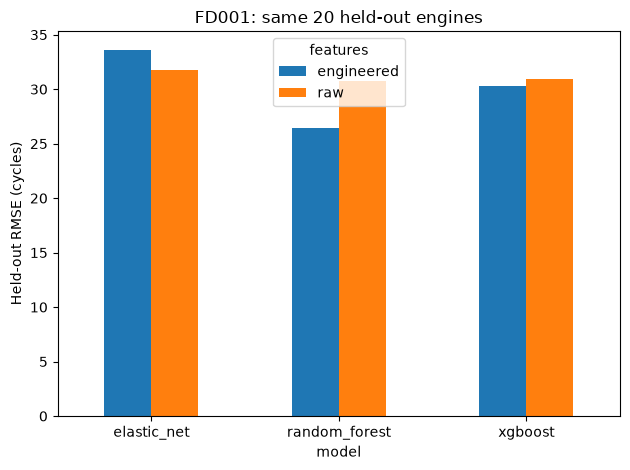

('raw', 'random_forest') {'early': {'n': 2050, 'rmse': 36.01452765299428, 'mae': 29.353477424397724, 'nasa_score': 171151.62654367805}, 'mid': {'n': 1000, 'rmse': 31.584219556739153, 'mae': 25.59807654744765, 'nasa_score': 70448.41752718859}, 'late': {'n': 1020, 'rmse': 13.795863048919822, 'mae': 9.20730619945917, 'nasa_score': 5199.374444539684}}
('raw', 'xgboost') {'early': {'n': 2050, 'rmse': 36.44505038046798, 'mae': 29.62014815725931, 'nasa_score': 179072.199866816}, 'mid': {'n': 1000, 'rmse': 31.060129583227592, 'mae': 25.30064441871643, 'nasa_score': 80796.17609639597}, 'late': {'n': 1020, 'rmse': 13.984236464601224, 'mae': 9.611653224860921, 'nasa_score': 5757.875389353189}}
('raw', 'elastic_net') {'early': {'n': 2050, 'rmse': 33.73529570574281, 'mae': 25.82467798869937, 'nasa_score': 207454.85768554875}, 'mid': {'n': 1000, 'rmse': 32.03402134352141, 'mae': 27.13784702686962, 'nasa_score': 75795.3818434436}, 'late': {'n': 1020, 'rmse': 26.953303690653506, 'mae': 22.025965396560

In [3]:
comparison = results.pivot(index="model", columns="features", values="holdout_rmse")
display(comparison)
comparison.plot.bar(ylabel="Held-out RMSE (cycles)", title="FD001: same 20 held-out engines", rot=0)
plt.tight_layout()
plt.show()
for key, scores in holdout_scores.items():
    print(key, scores["by_stage"])

## SHAP: engineered tree models
Explain a fixed sample of 200 held-out cycles. Transform complete held-out engine trajectories **before** sampling, so each rolling predictor retains its observed history. Tree-path-dependent SHAP uses the fitted tree training paths as its reference distribution. Positive contributions raise predicted RUL; negative contributions lower it. Mean absolute SHAP measures magnitude in cycles. Correlated sensors and rolling variants can share credit; attribution is not causal.

/Users/milindbansal/Vs Code/Web Dev/Project/cmapss-rul-hybrid/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


random_forest: SHAP additivity verified on 200 held-out cycles


,mean absolute SHAP (cycles)
cycle,29.150843
s_11_health_5,5.014374
s_4_mean_10,3.935486
s_4_mean_5,3.706842
s_11_health_10,3.337604
s_20_health_20,2.993587
s_15_mean_10,2.902416
s_3_mean_10,2.255518
s_20_health_10,2.219404
s_9_health_10,2.086781


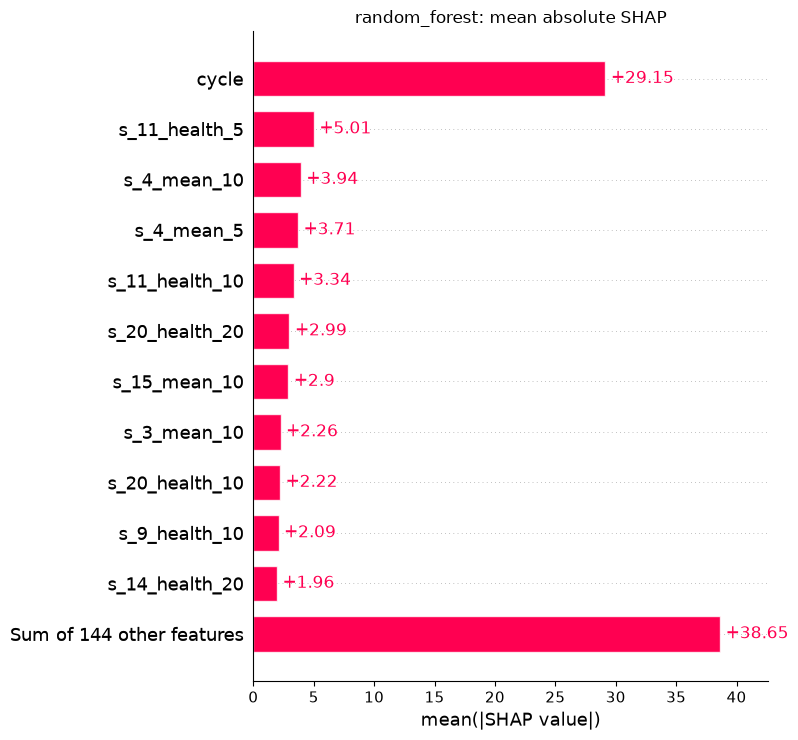

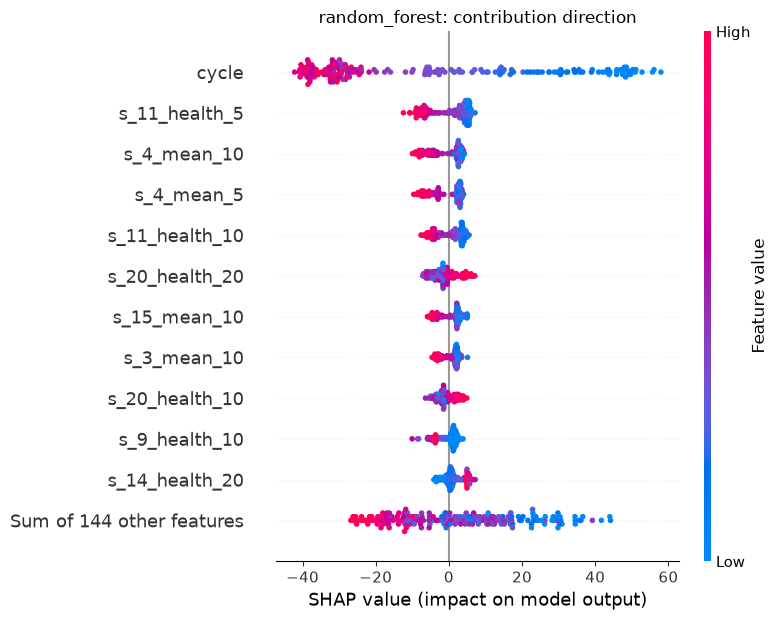

xgboost: SHAP additivity verified on 200 held-out cycles


,mean absolute SHAP (cycles)
cycle,22.188410
s_11_health_5,6.959602
s_11_health_10,5.884211
s_4_mean_5,5.306198
s_20_health_10,4.752004
s_15_health_20,4.593582
s_14_health_20,4.399606
s_14_mean_20,3.789373
s_3_mean_20,3.353104
s_2_health_20,3.241053


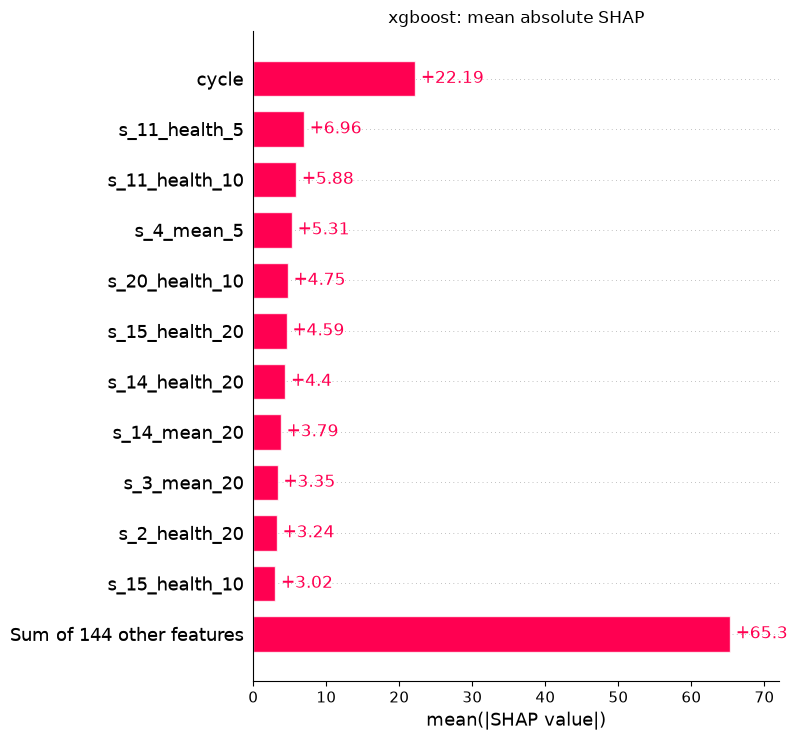

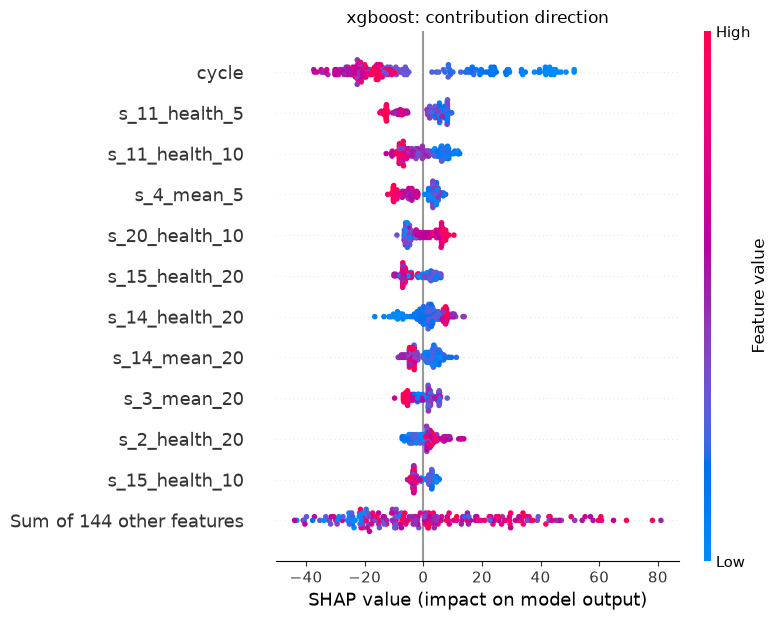

In [4]:
import shap

shap_importance = {}
for name in ("random_forest", "xgboost"):
    best = searches["engineered"][name].best_estimator_
    complete_features = best.named_steps["features"].transform(validation)
    explained_features = complete_features.sample(n=min(200, len(complete_features)), random_state=SEED)
    model = best.named_steps["model"]
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent", model_output="raw")
    explanation = explainer(explained_features)
    reconstructed = explanation.base_values + explanation.values.sum(axis=1)
    np.testing.assert_allclose(reconstructed, model.predict(explained_features), rtol=1e-4, atol=1e-4)
    importance = pd.Series(np.abs(explanation.values).mean(axis=0), index=explained_features.columns).sort_values(ascending=False)
    shap_importance[name] = importance
    print(f"{name}: SHAP additivity verified on {len(explained_features)} held-out cycles")
    display(importance.head(12).rename("mean absolute SHAP (cycles)").to_frame())
    shap.plots.bar(explanation, max_display=12, show=False)
    plt.title(f"{name}: mean absolute SHAP")
    plt.tight_layout()
    plt.show()
    shap.plots.beeswarm(explanation, max_display=12, show=False)
    plt.title(f"{name}: contribution direction")
    plt.tight_layout()
    plt.show()


## Reading the results
Use CV RMSE to choose parameters, then read the matched holdout table as an internal comparison. One subset and one holdout split cannot establish general superiority. The NASA score is particularly sensitive to large overestimates of remaining life. SHAP rankings describe these fitted models on the sampled holdout cycles; correlated feature variants and the inclusion of cycle influence the ranking. The final test-set decision remains with #6.

### Observed FD001 findings

Random Forest holdout RMSE falls from **30.759 to 26.472 cycles**; XGBoost from **30.904 to 30.330**. Elastic Net rises from **31.740 to 33.628**. None improves mean CV RMSE: raw/engineered values are 39.158/39.265, 39.892/40.871, and 42.651/42.882 respectively. The single holdout improvement therefore does not establish general superiority. Engineered XGBoost's NASA score rises from 265,626 to 390,805 despite the small RMSE improvement.

Selected parameters (in addition to the fixed factory settings):

| Model | Raw | Engineered |
|---|---|---|
| Random Forest | 100 trees; minimum leaf size 3 | 100 trees; minimum leaf size 3 |
| XGBoost | 100 trees; maximum depth 3 | 100 trees; maximum depth 3 |
| Elastic Net | alpha 0.1; l1 ratio 0.8 | alpha 1.0; l1 ratio 0.2 |

Cycle has the largest individual mean absolute SHAP contribution: **29.151 cycles** for Random Forest and **22.188** for XGBoost. Higher observed cycle values generally lower predicted RUL in the beeswarm plots. `s_11_health_5` ranks next in both models (5.014 and 6.960 cycles); rolling means and other health features also contribute. The aggregated “other features” bar combines 144 predictors and is not one competing feature. These attributions describe fitted-model behavior on the 200 sampled cycles.


In [5]:
for name in comparison.index:
    change = comparison.loc[name, "engineered"] - comparison.loc[name, "raw"]
    print(f"{name}: engineered minus raw holdout RMSE = {change:.3f} cycles")
for name, importance in shap_importance.items():
    print(f"{name}: largest sampled mean absolute contribution is {importance.index[0]} ({importance.iloc[0]:.3f} cycles)")
from importlib.metadata import version
print({name: version(name) for name in ("numpy", "pandas", "scikit-learn", "xgboost", "shap")})
cache.cleanup()


elastic_net: engineered minus raw holdout RMSE = 1.888 cycles
random_forest: engineered minus raw holdout RMSE = -4.287 cycles
xgboost: engineered minus raw holdout RMSE = -0.574 cycles
random_forest: largest sampled mean absolute contribution is cycle (29.151 cycles)
xgboost: largest sampled mean absolute contribution is cycle (22.188 cycles)
{'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'xgboost': '3.4.1', 'shap': '0.52.0'}
